# Automated CSV Profiler

## Step 1: Configuration and loading the CSV

In [1]:
# Importing pandas library
import pandas as pd

In [2]:
def load_csv(path):
    """Read every column as text, so our program decides the types itself."""
    # Read all columns as text
    df = pd.read_csv(path, dtype=str)

    # Clean each column one at a time 
    for col in df.columns: 
        # Remove extra spaces around values
        df[col] = df[col].str.strip()
        # Set empty cells as missing
        df.loc[df[col] == "", col] = None
    
    # Return new cleaned table
    return df

## Step 2: Column types and roles (Dataset Overview)

In [3]:
def numeric_share(values):
    """Share of non-missing values that can be read as numbers (0 to 1)."""
    
    # Skip missing cells
    values = values.dropna()

    # Edge case if column is empty
    if len(values) == 0:
        return 0

    # Convert values to numbers, non-numbers become missing
    numbers = pd.to_numeric(values, errors="coerce")

    # Count how many values became numbers
    count = numbers.notna().sum()

    # Return share of values that are numbers
    return count / len(values)

In [4]:
# Words in a column name that suggest an ID or code
ID_WORDS = ["id", "key", "code", "zip", "postal", "fips", "geoid",
            "district", "ward", "tract", "precinct"]


def get_words(name):
    """
    SPLITS A COLUMN NAME INTO LOWERCASE WORDS
    """
    # Lowercase the column name
    name = name.lower()

    # Replace symbols with spaces
    for symbol in ["_", "-", "(", ")", "."]:
        name = name.replace(symbol, " ")

    # Split name into words at the spaces
    return name.split()


def has_id_word(name):
    """
    CHECKS IF A COLUMN NAME CONTAINS AN ID WORD
    """
    # Check each word in the column name
    for word in get_words(name):
        # Return True if word is an ID word
        if word in ID_WORDS:
            return True

    # No ID words found
    return False


def numeric_type(numbers):
    """
    DECIDES IF A NUMERIC COLUMN HOLDS WHOLE NUMBERS OR DECIMALS
    """
    # Remainder after dividing by 1 is 0 for whole numbers
    remainders = numbers % 1

    # Integer if every remainder is 0
    if (remainders == 0).all():
        return "integer"

    # Otherwise decimals
    return "float"


def numeric_role(name, numbers):
    """
    DECIDES IF A NUMERIC COLUMN IS A MEASUREMENT OR AN IDENTIFIER
    """
    # Rule 1: Name contains an ID word
    if has_id_word(name):
        return "Identifier-like field", "name suggests an ID or code"

    # Rule 2: Values count up by 1 like row numbers
    if len(numbers) >= 20:
        # Difference between each value and the one before it
        differences = numbers.diff().dropna()
        if (differences == 1).all():
            return "Identifier-like field", "values count up by 1, like row numbers"

    # Rule 3: Otherwise a numeric measure, flag if few distinct values
    if numbers.nunique() <= 10:
        return "Numeric measure", "few distinct values: could be a count, a scale or a code"

    return "Numeric measure", ""

In [5]:
# List of valid boolean values
BOOLEAN_VALUES = ["true", "false", "yes", "no", "y", "n", "t", "f", "0", "1"]


def is_boolean(values):
    """
    CHECKS IF A COLUMN IS BOOLEAN (ONLY YES/NO STYLE VALUES)
    """
    # Skip missing cells
    values = values.dropna()

    # Edge case if column is empty
    if len(values) == 0:
        return False

    # Get distinct values in lowercase
    distinct = values.str.lower().unique()

    # Boolean columns have at most 2 distinct values
    if len(distinct) > 2:
        return False

    # Check every distinct value is a yes/no word
    for value in distinct:
        if value not in BOOLEAN_VALUES:
            return False

    # All checks passed
    return True


def looks_like_date(text):
    """
    CHECKS IF A VALUE IS SHAPED LIKE A DATE, E.G. 2024-03-15 OR 03/15/2024
    """
    # Dates start with a digit
    if not text[0].isdigit():
        return False

    # Dates have two dashes (2024-03-15) or two slashes (03/15/2024)
    if text.count("-") == 2 or text.count("/") == 2:
        return True

    # Otherwise not shaped like a date
    return False


def date_share(values):
    """
    FINDS THE SHARE OF VALUES THAT ARE REAL DATES
    """
    # Skip missing cells
    values = values.dropna()

    # Edge case if column is empty
    if len(values) == 0:
        return 0

    # Count values shaped like dates
    count = 0
    for value in values:
        if looks_like_date(value):
            count += 1

    # Stop if less than 80% are shaped like dates
    if count / len(values) < 0.8:
        return 0

    # Convert to dates, impossible dates become missing
    parsed = pd.to_datetime(values, errors="coerce", format="mixed")

    # Return share of values that became dates
    return parsed.notna().sum() / len(values)

In [6]:
def text_role(name, values):
    """
    DECIDES IF A TEXT COLUMN IS AN IDENTIFIER, FREE TEXT OR A CATEGORY
    """
    # Skip missing cells
    values = values.dropna()

    # Count values and distinct values
    n = len(values)
    n_unique = values.nunique()

    # Edge case if column is empty
    if n == 0:
        return "Unknown or mixed type", "all values are missing"

    # Share of values that are distinct, 1 means every value is different
    unique_ratio = n_unique / n

    # Count words in every value
    total_words = 0
    for value in values:
        total_words += len(value.split())

    # Average words per value
    avg_words = total_words / n

    # Rule 1: ID word in name and at least half the values are distinct
    if has_id_word(name) and unique_ratio >= 0.5:
        return "Identifier-like field", "name suggests an ID; values mostly unique"

    # Rule 2: Almost all values distinct and short (3 words or fewer)
    if n >= 20 and unique_ratio >= 0.95 and avg_words <= 3:
        return "Identifier-like field", str(round(unique_ratio * 100)) + "% of values are unique"

    # Rule 3: Long values (5+ words) and mostly distinct
    if avg_words >= 5 and unique_ratio >= 0.5:
        return "Free-text field", "long values (about " + str(round(avg_words)) + " words each)"

    # Rule 4: Otherwise a category, flag if more than 50 categories
    if n_unique > 50:
        return "Categorical attribute", "high cardinality (" + str(n_unique) + " categories)"

    return "Categorical attribute", ""

In [7]:
def infer_column(series):
    """
    PROFILES ONE COLUMN: TECHNICAL TYPE, ROLE, COUNTS AND A NOTE
    RULES ARE CHECKED IN ORDER AND THE FIRST MATCH WINS
    """
    # Set column name and non-missing values
    name = str(series.name)
    values = series.dropna()
    n_rows = len(series)
    n_valid = len(values)

    # Percentage of missing cells
    if n_rows > 0:
        missing_pct = round((n_rows - n_valid) / n_rows * 100, 2)
    else:
        missing_pct = 0

    # Set profile with counts from Step 1
    info = {
        "column": name,
        "technical_type": "",
        "role": "",
        "non_missing": n_valid,
        "missing_%": missing_pct,
        "unique": values.nunique(),
        "note": "",
    }

    # Rule 1: Edge case if all values are missing
    if n_valid == 0:
        info["technical_type"] = "empty"
        info["role"] = "Unknown or mixed type"
        info["note"] = "all values are missing"
        return info

    # Rule 2: Check for boolean first since 0/1 are also numbers
    if is_boolean(values):
        info["technical_type"] = "boolean"
        info["role"] = "Boolean field"
        return info

    # Rule 3: Numeric if at least 95% of values are numbers
    share = numeric_share(values)
    if share >= 0.95:
        # Convert values to numbers
        numbers = pd.to_numeric(values, errors="coerce").dropna()
        # Set technical type, role and note
        info["technical_type"] = numeric_type(numbers)
        role, note = numeric_role(name, numbers)
        info["role"] = role
        info["note"] = note
        # Count values that are not numbers
        bad = n_valid - len(numbers)
        if bad > 0:
            if note == "":
                info["note"] = f"{bad} value(s) are not numbers"
            else:
                info["note"] = note + f"; {bad} value(s) are not numbers"
        return info

    # Rule 4: Mixed if between 20% and 95% of values are numbers
    if share >= 0.2:
        info["technical_type"] = "mixed"
        info["role"] = "Unknown or mixed type"
        info["note"] = f"{round(share * 100)}% of values are numbers, the rest are text"
        return info

    # Rule 5: Date-like if at least 90% of values are dates
    if date_share(values) >= 0.9:
        info["technical_type"] = "datetime"
        info["role"] = "Date-like field"
        info["note"] = "ambiguous dates like 03/04 are read month-first"
        return info

    # Rule 6: Remaining columns are text (identifier, free text or category)
    info["technical_type"] = "string"
    role, note = text_role(name, values)
    info["role"] = role
    info["note"] = note
    return info


def profile_columns(table):
    """
    PROFILES EVERY COLUMN OF A TABLE
    """
    # Empty list of column profiles
    profiles = []

    # Profile each column
    for col in table.columns:
        profiles.append(infer_column(table[col]))

    # Return profiles as a table
    return pd.DataFrame(profiles)

## Step 3: Data Quality Checks

In [8]:
# Threshold for high missingness (percent of rows)
HIGH_MISSING_THRESHOLD = 30

# Words in a column name that suggest sensitive information
SENSITIVE_WORDS = {
    "name": "may contain names of people",
    "email": "may contain email addresses",
    "phone": "may contain phone numbers",
    "address": "may contain street addresses",
    "street": "may contain street addresses",
    "zip": "postal code, can help identify where someone lives",
    "postal": "postal code, can help identify where someone lives",
    "location": "may contain precise locations",
    "latitude": "may contain precise locations",
    "longitude": "may contain precise locations",
    "ssn": "may contain Social Security numbers",
    "birth": "may contain dates of birth",
    "dob": "may contain dates of birth",
    "vin": "name suggests an identification number",
    "age": "demographic attribute, consider bias",
    "gender": "demographic attribute, consider bias",
    "sex": "demographic attribute, consider bias",
    "race": "demographic attribute, consider bias",
    "ethnicity": "demographic attribute, consider bias",
    "religion": "demographic attribute, consider bias",
    "income": "personal financial information",
    "salary": "personal financial information",
    "patient": "may contain health information",
    "medical": "may contain health information",
    "diagnosis": "may contain health information",
}


def count_duplicates(table):
    """
    COUNTS ROWS THAT ARE EXACT COPIES OF AN EARLIER ROW
    """
    # Mark each row that repeats an earlier row
    duplicated = table.duplicated()

    # Count repeated rows
    count = int(duplicated.sum())

    # Edge case if table has no rows
    if len(table) == 0:
        return count, 0

    # Return count and percentage
    return count, round(count / len(table) * 100, 2)


def looks_like_email(text):
    """
    CHECKS IF A VALUE LOOKS LIKE AN EMAIL ADDRESS
    """
    # Emails need an @
    if "@" not in text:
        return False

    # Part after the @ needs a dot, like gmail.com
    domain = text.split("@")[-1]
    return "." in domain


def looks_like_phone(text):
    """
    CHECKS IF A VALUE LOOKS LIKE A US PHONE NUMBER
    """
    # Keep only the digits
    digits = ""
    for character in text:
        if character.isdigit():
            digits += character

    # Phone numbers have 10 digits
    return len(digits) == 10 and len(text) <= 14


def sensitive_reasons(name, values):
    """
    FINDS REASONS A COLUMN MAY HOLD SENSITIVE INFORMATION (A HEURISTIC, NOT A GUARANTEE)
    """
    # Empty list of reasons
    reasons = []

    # Check each word in the column name
    for word in get_words(name):
        if word in SENSITIVE_WORDS:
            reasons.append(SENSITIVE_WORDS[word])

    # Check the first 500 values for email and phone patterns
    sample = values.dropna().head(500)
    if len(sample) > 0:
        email_count = 0
        phone_count = 0
        for value in sample:
            if looks_like_email(value):
                email_count += 1
            if looks_like_phone(value):
                phone_count += 1

        # Flag if at least 20% of values match a pattern
        if email_count / len(sample) >= 0.2:
            reasons.append("values look like email addresses")
        if phone_count / len(sample) >= 0.2:
            reasons.append("values look like phone numbers")

    # Return reasons found
    return reasons


def quality_checks(table, profile):
    """
    RUNS THE DATA QUALITY CHECKS. PROBLEMS ARE ONLY FLAGGED, NOTHING IS CHANGED
    """
    # Count duplicate rows
    dup_count, dup_pct = count_duplicates(table)

    # Empty lists for each check
    empty_columns = []
    constant_columns = []
    high_missing = []
    mixed_types = []
    high_cardinality = []
    sensitive = []

    # Check each column's profile
    for index, row in profile.iterrows():
        col = row["column"]

        # Empty columns: every value missing
        if row["technical_type"] == "empty":
            empty_columns.append(col)

        # Constant columns: only one distinct value
        if row["unique"] == 1:
            constant_columns.append(col)

        # High missingness: at or above the threshold (empty columns listed separately)
        if row["missing_%"] >= HIGH_MISSING_THRESHOLD and row["technical_type"] != "empty":
            high_missing.append(col + " (" + str(row["missing_%"]) + "%)")

        # Mixed types: part numbers part text, or numeric with some text values
        if row["technical_type"] == "mixed" or "not numbers" in row["note"]:
            mixed_types.append(col)

        # Identifiers, free text, or categories with more than 50 values
        if row["role"] == "Identifier-like field" or row["role"] == "Free-text field":
            high_cardinality.append(col)
        elif row["role"] == "Categorical attribute" and row["unique"] > 50:
            high_cardinality.append(col)

        # Potentially sensitive fields
        reasons = sensitive_reasons(col, table[col])
        if len(reasons) > 0:
            sensitive.append(col + ": " + "; ".join(reasons))

    # Return every result
    return {
        "duplicate_rows": dup_count,
        "duplicate_%": dup_pct,
        "empty_columns": empty_columns,
        "constant_columns": constant_columns,
        "high_missing_threshold_%": HIGH_MISSING_THRESHOLD,
        "high_missing_columns": high_missing,
        "mixed_type_columns": mixed_types,
        "high_cardinality_columns": high_cardinality,
        "sensitive_columns": sensitive,
        "sensitive_note": "Sensitive-field detection is only a heuristic based on column names "
                          "and simple value patterns. No warning does NOT mean the data is safe.",
    }


def print_quality(results):
    """
    PRINTS THE QUALITY RESULTS ONE PER LINE
    """
    # Print each check and its result
    for check in results:
        print(check, ":", results[check])

## Step 4: Descriptive Statistics

In [9]:
# Ten most frequent values for categorical columns
TOP_N = 10


def round2(x):
    """
    ROUNDS A NUMBER TO 2 DECIMALS
    """
    # Convert to a float and round
    return round(float(x), 2)


def numeric_stats(series):
    """
    CALCULATES DESCRIPTIVE STATISTICS FOR ONE NUMERIC COLUMN
    OUTLIERS USE THE 1.5 X IQR RULE AND ARE ONLY COUNTED, NEVER REMOVED
    """
    # Convert values to numbers and skip missing cells
    numbers = pd.to_numeric(series, errors="coerce")
    valid = numbers.dropna()

    # Valid and missing counts
    valid_count = len(valid)
    missing_count = len(series) - valid_count

    # Set stats with counts
    stats = {
        "valid_count": valid_count,
        "missing_count": missing_count,
        "missing_%": round2(missing_count / len(series) * 100),
    }

    # Edge case if no valid numbers
    if valid_count == 0:
        return stats

    # First quartile, third quartile and interquartile range
    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    iqr = q3 - q1

    # Outlier fences: 1.5 x IQR below Q1 and above Q3
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    # Keep only the values below the lower fence, and above the upper fence
    below = valid[valid < lower_fence]
    above = valid[valid > upper_fence]
    outlier_count = len(below) + len(above)

    # Mode only meaningful if some value repeats
    if valid.nunique() < valid_count:
        mode = round2(valid.mode()[0])
    else:
        mode = "none (every value appears once)"

    # Add remaining statistics
    stats["min"] = round2(valid.min())
    stats["max"] = round2(valid.max())
    stats["mean"] = round2(valid.mean())
    stats["median"] = round2(valid.median())
    stats["mode"] = mode
    stats["std"] = round2(valid.std())
    stats["q1"] = round2(q1)
    stats["q3"] = round2(q3)
    stats["iqr"] = round2(iqr)
    stats["outlier_count"] = outlier_count
    stats["outlier_%"] = round2(outlier_count / valid_count * 100)

    # Return statistics
    return stats


def categorical_stats(series):
    """
    CALCULATES FREQUENCY COUNTS FOR ONE CATEGORICAL COLUMN
    """
    # Skip missing cells
    values = series.dropna()
    n = len(values)

    # Edge case if column is empty
    if n == 0:
        return {"n_categories": 0}

    # Count each category, most common first
    counts = values.value_counts()

    # Top categories with counts and percentages
    top_values = []
    for value, count in counts.head(TOP_N).items():
        top_values.append({"value": value, "count": int(count), "percent": round2(count / n * 100)})

    # Return statistics
    return {
        "n_categories": len(counts),
        "most_frequent": list(values.mode()),
        "top_values": top_values,
    }


def describe(table, profile):
    """
    RUNS THE RIGHT STATISTICS FOR EACH COLUMN BASED ON ITS ROLE
    """
    # Empty results for each kind of column
    results = {"numeric": {}, "categorical": {}, "skipped": []}

    # Pick statistics by role
    for index, row in profile.iterrows():
        col = row["column"]
        if row["role"] == "Numeric measure":
            results["numeric"][col] = numeric_stats(table[col])
        elif row["role"] == "Categorical attribute" or row["role"] == "Boolean field":
            results["categorical"][col] = categorical_stats(table[col])

    # Explain skipped analyses
    if len(results["numeric"]) == 0:
        results["skipped"].append("Numeric statistics skipped: no numeric measure columns found.")
    if len(results["categorical"]) == 0:
        results["skipped"].append("Categorical statistics skipped: no categorical or Boolean columns found.")

    # Return all statistics
    return results

## Step 5: Relationships Between Variables

In [10]:
def strength(r):
    """
    GIVES A WORD FOR HOW STRONG A CORRELATION IS
    """
    # Size of the correlation, ignoring the sign
    size = abs(r)

    # Pick a label by size
    if size < 0.1:
        return "negligible"
    elif size < 0.3:
        return "weak"
    elif size < 0.5:
        return "moderate"
    elif size < 0.8:
        return "strong"
    else:
        return "very strong"


def relationships(table, stats):
    """
    CORRELATION BETWEEN NUMERIC MEASURE COLUMNS
    CORRELATION SHOWS ASSOCIATION ONLY, NOT CAUSATION
    """
    # Note saved with the results
    note = "Correlation shows association only, never causation."

    # Names of the numeric measure columns
    columns = list(stats["numeric"].keys())

    # Edge case if fewer than 2 numeric columns
    if len(columns) < 2:
        return {"matrix": None, "pairs": [], "strongest_positive": None, "strongest_negative": None,
                "skipped": "Correlation skipped: at least 2 numeric measure columns are needed.",
                "note": note}

    # Table with only the numeric columns, as numbers
    numbers = pd.DataFrame()
    for col in columns:
        numbers[col] = pd.to_numeric(table[col], errors="coerce")

    # Correlation matrix: r for every pair of columns
    matrix = numbers.corr()

    # Empty list of pairs
    pairs = []

    # Check every pair once
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            # Names of the two columns in this pair
            a = columns[i]
            b = columns[j]

            # Look up r for this pair in the matrix
            r = matrix.loc[a, b]

            # Skip pairs with no r
            if pd.isna(r):
                continue

            # Add pair to list with its strength label
            pairs.append({"column_a": a, "column_b": b, "r": round2(r), "strength": strength(r)})

    # Strongest positive: highest r above 0
    strongest_positive = None
    highest_r = 0
    for pair in pairs:
        if pair["r"] > highest_r:
            highest_r = pair["r"]
            strongest_positive = pair

    # Strongest negative: lowest r below 0
    strongest_negative = None
    lowest_r = 0
    for pair in pairs:
        if pair["r"] < lowest_r:
            lowest_r = pair["r"]
            strongest_negative = pair

    # Return results
    return {
        "matrix": matrix.round(2),
        "pairs": pairs,
        "strongest_positive": strongest_positive,
        "strongest_negative": strongest_negative,
        "skipped": "",
        "note": note,
    }

## Step 6: Visualizations

In [11]:
# Import plotting libraries
import os
import matplotlib.pyplot as plt
import seaborn as sns


def short_label(text):
    """
    SHORTENS LONG LABELS SO THEY STAY READABLE ON A PLOT
    """
    # Turn into text
    text = str(text)

    # Cut long labels
    if len(text) > 30:
        return text[:27] + "..."
    return text


def save_plot(folder, plots, title, why):
    """
    SAVES THE CURRENT PLOT AS .png FILES AND WHY IT WAS CHOSEN 
    """
    # Next file name
    number = len(plots) + 1
    if number < 10:
        file_name = "plot_0" + str(number) + ".png"
    else:
        file_name = "plot_" + str(number) + ".png"

    # Save the plot as an image and show it in the notebook
    plt.tight_layout()
    plt.savefig(folder + "/" + file_name)
    plt.show()
    plt.close()

    # Record the plot
    plots.append({"file": "plots/" + file_name, "title": title, "why": why})

def plot_missing(profile, folder, plots):
    """
    BAR CHART OF THE MISSING PERCENTAGE FOR COLUMNS WITH MISSING VALUES
    """
    # Columns with at least 1% missing
    missing = profile[profile["missing_%"] >= 1]

    # Draw bar chart with the 30% threshold line
    plt.figure(figsize=(8, 5))
    sns.barplot(data=missing, x="missing_%", y="column")
    plt.axvline(HIGH_MISSING_THRESHOLD, color="red", linestyle="--", label="30% threshold")
    plt.title("Missing values by column")
    plt.xlabel("Missing values (% of rows)")
    plt.ylabel("Column")
    plt.legend()
    
    # Why: Chose this since it demonstrates which columns have gaps, compared to the 30% threshold
    why = "Chosen to show which columns have missing values, and how close they are to the 30% threshold."
    save_plot(folder, plots, "Missing values by column", why)

def plot_histogram(table, col, folder, plots):
    """
    HISTOGRAM OF ONE NUMERIC COLUMN
    """
    # Convert values to numbers and skip missing cells
    values = pd.to_numeric(table[col], errors="coerce").dropna()

    # Draw histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(values, bins=30)
    plt.title("Distribution of " + short_label(col))
    plt.xlabel(short_label(col))
    plt.ylabel("Number of rows")
    
    # Why: shows the shape of a numeric column
    why = "Chosen because it shows the distribution of a numeric column: clusters, skew, and peaks."
    save_plot(folder, plots, "Distribution of " + col, why)

def plot_boxplot(table, col, folder, plots):
    """
    BOXPLOT OF ONE NUMERIC COLUMN, DOTS ARE 1.5 X IQR OUTLIERS
    """
    # Convert values to numbers and skip missing cells
    values = pd.to_numeric(table[col], errors="coerce").dropna()

    # Draw boxplot
    plt.figure(figsize=(6, 5))
    sns.boxplot(y=values)
    plt.title("Boxplot of " + short_label(col) + " (1.5 x IQR outliers)")
    plt.xlabel(short_label(col))
    plt.ylabel("Value")
    
    # Why: shows the 1.5 x IQR outliers
    why = "Chosen because it shows the median, the spread and the 1.5 x IQR outliers of the numeric column with the most outliers"
    save_plot(folder, plots, "Boxplot of " + col, why)

def plot_bar_chart(stats, col, folder, plots):
    """
    BAR CHART OF THE MOST FREQUENT VALUES OF ONE CATEGORICAL COLUMN
    """
    # Labels and counts of the top categories
    labels = []
    counts = []
    for item in stats["categorical"][col]["top_values"]:
        labels.append(short_label(item["value"]))
        counts.append(item["count"])

    # Draw bar chart
    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts, y=labels)
    plt.title("Most frequent values of " + short_label(col))
    plt.xlabel("Number of rows")
    plt.ylabel(short_label(col))
                           
    # Why: compares how many rows fall in each category
    why = "Chosen because it compares how many rows fall in each category of a column with 2 to 10 categories"
    save_plot(folder, plots, "Most frequent values of " + col, why)

def plot_heatmap(rel, folder, plots):
    """
    HEATMAP OF THE CORRELATION MATRIX
    """
    # Shorten long column names on the axes
    matrix = rel["matrix"].rename(index=short_label, columns=short_label)

    # Draw heatmap with each r value written in its square
    plt.figure(figsize=(7, 6))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation between numeric columns")
    plt.xlabel("Column")
    plt.ylabel("Column")

    # Why: shows every correlation at once
    why = "Chosen because it shows the correlation between every pair of numeric measure columns at once"
    save_plot(folder, plots, "Correlation between numeric columns", why)


def plot_scatter(table, pair, folder, plots):
    """
    SCATTERPLOT OF ONE PAIR OF NUMERIC COLUMNS
    """
    # Names of the two columns
    a = pair["column_a"]
    b = pair["column_b"]

    # Table with the two columns as numbers, skip missing rows
    data = pd.DataFrame()
    data[a] = pd.to_numeric(table[a], errors="coerce")
    data[b] = pd.to_numeric(table[b], errors="coerce")
    data = data.dropna()

    # Use a random sample of 5,000 rows so the plot stays readable
    if len(data) > 5000:
        data = data.sample(n=5000, random_state=1)
        
    # Draw scatterplot
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=data, x=a, y=b, s=10, alpha=0.3)
    plt.title(short_label(a) + " vs " + short_label(b) + " (r = " + str(pair["r"]) + ")")
    plt.xlabel(short_label(a))
    plt.ylabel(short_label(b))
    
    # Why: shows the strongest pair point by point
    why = "Chosen because it shows the pair with the strongest correlation point by point"
    save_plot(folder, plots, a + " vs " + b, why)


def plot_by_category(table, num, cat, folder, plots):
    """
    BOXPLOT OF A NUMERIC COLUMN FOR EACH CATEGORY OF A CATEGORICAL COLUMN
    """
    # Table with the category and the number, skip missing rows
    data = pd.DataFrame()
    data[cat] = table[cat]
    data[num] = pd.to_numeric(table[num], errors="coerce")
    data = data.dropna()
    data[cat] = data[cat].apply(short_label)

    # Draw one boxplot per category
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x=cat, y=num)
    plt.xticks(rotation=30, ha="right")
    plt.title(short_label(num) + " by " + short_label(cat))
    plt.xlabel(short_label(cat))
    plt.ylabel(short_label(num))

    # Why: compares a numeric column across categories
    why = "Chosen because it compares a numeric column across the categories of a small categorical column"
    save_plot(folder, plots, num + " by " + cat, why)


def make_plots(table, profile, stats, rel, folder):
    """
    CHOOSES PLOTS BASED ON THE COLUMN TYPES AND SAVES THEM (AT MOST 8)
    """
    # Create the plots folder if it does not exist
    os.makedirs(folder, exist_ok=True)

    # Empty lists for plots made and plots skipped
    plots = []
    skipped = []

    # Numeric measure columns
    numeric_columns = list(stats["numeric"].keys())

    # Categorical columns with 2 to 10 categories (readable on a plot)
    small_categorical = []
    for col in stats["categorical"]:
        n = stats["categorical"][col]["n_categories"]
        if n >= 2 and n <= 10:
            small_categorical.append(col)

    # Numeric column with the most outliers
    most_outliers = None
    highest = -1
    for col in numeric_columns:
        if stats["numeric"][col]["outlier_count"] > highest:
            highest = stats["numeric"][col]["outlier_count"]
            most_outliers = col

    # Strongest pair: biggest r, ignoring the sign
    strongest_pair = None
    biggest = 0
    for pair in rel["pairs"]:
        if abs(pair["r"]) > biggest:
            biggest = abs(pair["r"])
            strongest_pair = pair

    # 1. Missing values bar chart
    if len(profile[profile["missing_%"] >= 1]) > 0:
        plot_missing(profile, folder, plots)
    else:
        skipped.append("Missing-value bar chart: every column is less than 1% missing")

    # 2-3. Histograms of the first 2 numeric columns
    if len(numeric_columns) > 0:
        for col in numeric_columns[:2]:
            plot_histogram(table, col, folder, plots)
    else:
        skipped.append("Histogram: no numeric measure columns")

    # 4. Boxplot of the numeric column with the most outliers
    if most_outliers is not None:
        plot_boxplot(table, most_outliers, folder, plots)
    else:
        skipped.append("Boxplot: no numeric measure columns")

    # 5. Bar chart of the first small categorical column
    if len(small_categorical) > 0:
        plot_bar_chart(stats, small_categorical[0], folder, plots)
    else:
        skipped.append("Categorical bar chart: no categorical column with 2-10 categories")

    # 6. Correlation heatmap
    if rel["matrix"] is not None:
        plot_heatmap(rel, folder, plots)
    else:
        skipped.append("Correlation heatmap: " + rel["skipped"])

    # 7. Scatterplot of the strongest pair
    if strongest_pair is not None:
        plot_scatter(table, strongest_pair, folder, plots)
    else:
        skipped.append("Scatterplot: no pair of numeric columns to compare")

    # 8. Numeric column by category
    if most_outliers is not None and len(small_categorical) > 0:
        plot_by_category(table, most_outliers, small_categorical[0], folder, plots)
    else:
        skipped.append("Numeric by category: needs a numeric column and a categorical column with 2-10 categories")

    # Return plots made and plots skipped
    return plots, skipped

## Step 7: AI-Assisted Insights (Ollama)

In [12]:
# Import libraries for JSON and the Local LLM
import json
import ollama

# Local Ollama Model
MODEL = "qwen2.5:7b"

def build_summary(file_name, table, profile, quality, stats, rel):
    """
    BUILDS THE STRUCTURED SUMMARY OF VERIFIED PYTHON RESULTS
    """
    # Put every Python result into one dictionary
    summary = {
        "file_name": file_name,
        "rows": len(table),
        "columns": len(table.columns),
        "column_profile": profile.to_dict(orient="records"),
        "data_quality": quality,
        "statistics": stats,
        "strongest_positive": rel["strongest_positive"],
        "strongest_negative": rel["strongest_negative"],
        "correlation_pairs": rel["pairs"],
        "correlation_skipped": rel["skipped"],
    }

    # Return summary
    return summary


def build_prompt(summary):
    """
    WRITES THE PROMPT: RULES FOR THE LLM PLUS THE VERIFIED SUMMARY AS JSON
    """
    # Rules for the LLM
    rules = [
        "Hello, you're assigned the role of a data quality assistant.",
        "You will be provided a structured summary of a dataset.",
        "Every number in the summary was calculated and verified by Python.",
        "Your job is to write insights about the dataset.",
        "I would want you to write between 5 and 8 short insights.",
        "Please put each insight on its own line, starting with a dash and the type of insight in brackets.",
        "For example: - [Data quality] The column_name column is missing for 100 of 1000 rows (10.0%).",
        "Make sure to include at least one [Data quality] finding.",
        "Make sure to include at least one [Distribution] finding.",
        "Make sure to include at least one [Categorical] finding, if there are categorical columns.",
        "Make sure to include at least one [Relationship] finding, if there are correlations.",
        "Make sure to include at least one [Limitation] or potential-bias warning.",
        "Make sure to include at least one [Question] recommended for further investigation.",
        "Additionally, every insight that uses a number should name the column and give the number.",
        "Please only use numbers that are present in the summary, don't calculate any new numbers.",
        "Please don't guess what a column or abbreviation means, and don't assume units.",
        "Make sure to not describe correlation as causation.",
        "Make sure to not present guesses as facts.",
        "Here is the dataset summary:",
    ]
    
    # Join the rules into one text, each on its own line
    prompt = "\n".join(rules)
   
    # Add the summary as JSON text after the rules
    return prompt + "\n" + json.dumps(summary, default=str)


def ask_llm(prompt):
    """
    SENDS THE PROMPT TO THE LOCAL OLLAMA MODEL AND RETURNS ITS ANSWER
    """
    # Try to get an answer from the model
    try:
        response = ollama.chat(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            # Give the model enough reading space for the whole prompt
            options={"num_ctx": 8192}
        )
        return response["message"]["content"]

    # If Ollama is not running, skip the AI insights
    except Exception:
        print("LLM unavailable, AI insights skipped")
        return None

def find_numbers(text):
    """
    FINDS EVERY NUMBER IN A PIECE OF TEXT
    """
    # Empty list of numbers
    numbers = []

    # Check each word
    for word in text.split():
        # Remove punctuation around the word and commas inside it
        word = word.strip(".,;:()[]{}%*\"'").replace(",", "")

        # Keep the word if it is a number
        try:
            numbers.append(float(word))
        except ValueError:
            pass

    # Return numbers found
    return numbers


def check_numbers(response, summary):
    """
    FINDS NUMBERS IN THE LLM ANSWER THAT PYTHON NEVER CALCULATED
    """
    # Numbers Python calculated, and numbers the LLM wrote
    python_numbers = find_numbers(json.dumps(summary, default=str))
    llm_numbers = find_numbers(response)

    # Keep the LLM numbers that are not in Python's numbers
    unverified = []
    for number in llm_numbers:
        if number not in python_numbers:
            unverified.append(number)

    # Return numbers that could not be verified
    return unverified

## Step 8: Report and Output Files

In [13]:
def write_report(summary, profile, quality, stats, rel, plots, skipped_plots, llm_status, response, unverified, report_path):
    """
    WRITES THE REPORT AS A MARKDOWN FILE FROM THE PYTHON RESULTS
    """
    # Empty list of report lines
    lines = []

    # Title
    lines.append("# Data Profile: " + summary["file_name"])
    lines.append("")

    # ----- 1. Dataset overview -----
    lines.append("## 1. Dataset Overview")
    lines.append("- File name: " + summary["file_name"])
    lines.append("- Rows: " + str(summary["rows"]))
    lines.append("- Columns: " + str(summary["columns"]))
    lines.append("")
    lines.append("Column profile (roles are inferred from values and names; column meanings and units are unknown):")
    lines.append("```")
    lines.append(profile.to_string(index=False))
    lines.append("```")
    lines.append("")

    # ----- 2. Data quality -----
    lines.append("## 2. Data Quality")
    for check in quality:
        lines.append("- " + check + ": " + str(quality[check]))
    lines.append("")
    lines.append("High missingness threshold: " + str(HIGH_MISSING_THRESHOLD) + "% of rows. "
                 "Above this level, analysis of a column rests on less than 70% of the rows.")
    lines.append("Nothing was deleted or changed. Problems are only flagged.")
    lines.append("")

    # ----- 3. Descriptive statistics -----
    lines.append("## 3. Descriptive Statistics")
    for message in stats["skipped"]:
        lines.append("- " + message)
    if len(stats["numeric"]) > 0:
        lines.append("Numeric columns (outliers use the 1.5 x IQR rule and are only counted, never removed):")
        lines.append("```")
        lines.append(pd.DataFrame(stats["numeric"]).to_string())
        lines.append("```")
    for col in stats["categorical"]:
        col_stats = stats["categorical"][col]
        if col_stats["n_categories"] == 0:
            continue
        lines.append("")
        lines.append("**" + col + "**: " + str(col_stats["n_categories"]) + " categories, most frequent: "
                     + str(col_stats["most_frequent"]))
        lines.append("```")
        lines.append(pd.DataFrame(col_stats["top_values"]).to_string(index=False))
        lines.append("```")
    lines.append("")

    # ----- 4. Relationships -----
    lines.append("## 4. Relationships Between Variables")
    lines.append(rel["note"])
    if rel["matrix"] is None:
        lines.append("- " + rel["skipped"])
    else:
        lines.append("```")
        lines.append(rel["matrix"].to_string())
        lines.append("```")
        lines.append("- Strongest positive: " + str(rel["strongest_positive"]))
        lines.append("- Strongest negative: " + str(rel["strongest_negative"]))
    lines.append("")

    # ----- 5. Visualizations -----
    lines.append("## 5. Visualizations")
    for plot in plots:
        lines.append("### " + plot["title"])
        lines.append("![" + plot["title"] + "](" + plot["file"] + ")")
        lines.append("Why this plot: " + plot["why"])
        lines.append("")
    if len(skipped_plots) > 0:
        lines.append("Plot types skipped:")
        for message in skipped_plots:
            lines.append("- " + message)
    lines.append("")

    # ----- 6. AI-assisted insights -----
    lines.append("## 6. AI-Assisted Insights")
    if response is None:
        lines.append(llm_status)
    else:
        lines.append("Written by the local Ollama model " + MODEL + " from the Python summary (analysis_summary.json).")
        lines.append("")
        lines.append(response)
        lines.append("")
        lines.append("Verification: numbers in the insights that do not appear in the Python results: " + str(unverified))
        lines.append("This check confirms a number exists in the Python results, not that it is attached to the "
                     "right column, so each insight should be read against the statistics above.")
    lines.append("")

    # ----- 7. Limitations -----
    lines.append("## 7. Limitations")
    lines.append("- Column meanings, units and valid ranges are unknown; roles are inferred from values and names only.")
    lines.append("- The 1.5 x IQR rule flags many values in skewed columns; a flagged value is not necessarily an error.")
    lines.append("- Correlation shows association only, not causation.")
    lines.append("- " + quality["sensitive_note"])
    lines.append("- AI insights can attach a real number to the wrong column; they must be reviewed by a person.")

    # Save report
    with open(report_path, "w") as file:
        file.write("\n".join(lines))


def generate_profile(csv_path, output_dir, use_llm=True):
    """
    PROFILES ONE CSV FILE AND SAVES EVERY REQUIRED OUTPUT FILE IN output_dir
    """
    # Create the output and plots folders
    plots_dir = output_dir + "/plots"
    os.makedirs(plots_dir, exist_ok=True)

    # Remove plots from an earlier run
    for old_file in os.listdir(plots_dir):
        if old_file.startswith("plot_"):
            os.remove(plots_dir + "/" + old_file)

    # Steps 1 to 6: load, profile, quality, statistics, relationships, plots
    file_name = os.path.basename(csv_path)
    table = load_csv(csv_path)
    profile = profile_columns(table)
    quality = quality_checks(table, profile)
    stats = describe(table, profile)
    rel = relationships(table, stats)
    plots, skipped_plots = make_plots(table, profile, stats, rel, plots_dir)

    # Step 7: summary, prompt, LLM answer and number check
    summary = build_summary(file_name, table, profile, quality, stats, rel)
    prompt = build_prompt(summary)
    response = None
    unverified = []
    if use_llm:
        response = ask_llm(prompt)
        llm_status = "AI-generated narrative insights were skipped because the model was unavailable."
    else:
        llm_status = "AI-generated narrative insights were skipped because the LLM was turned off (use_llm=False)."
    if response is not None:
        unverified = check_numbers(response, summary)

    # Save column profile and structured summary
    profile.to_csv(output_dir + "/column_profile.csv", index=False)
    with open(output_dir + "/analysis_summary.json", "w") as file:
        json.dump(summary, file, indent=2, default=str)

    # Save LLM prompt and response
    with open(output_dir + "/llm_prompt.txt", "w") as file:
        file.write(prompt)
    with open(output_dir + "/llm_response.txt", "w") as file:
        if response is None:
            file.write(llm_status)
        else:
            file.write(response)

    # Save report
    write_report(summary, profile, quality, stats, rel, plots, skipped_plots,
                 llm_status, response, unverified, output_dir + "/report.md")
    print("Profile saved to", output_dir)

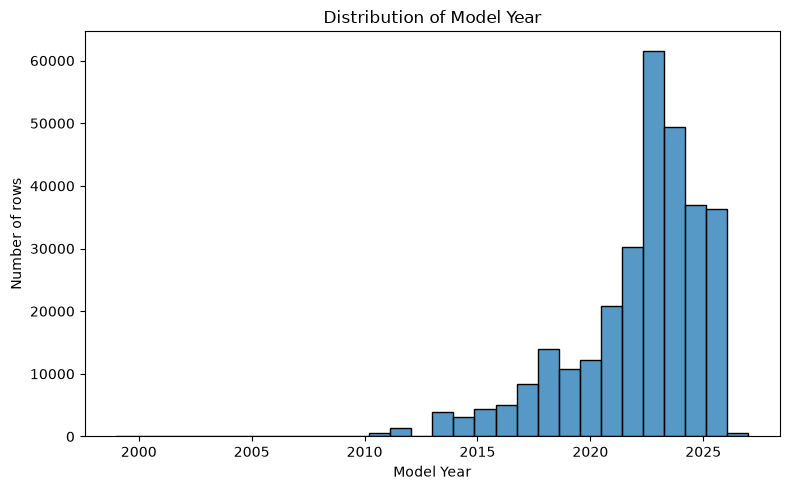

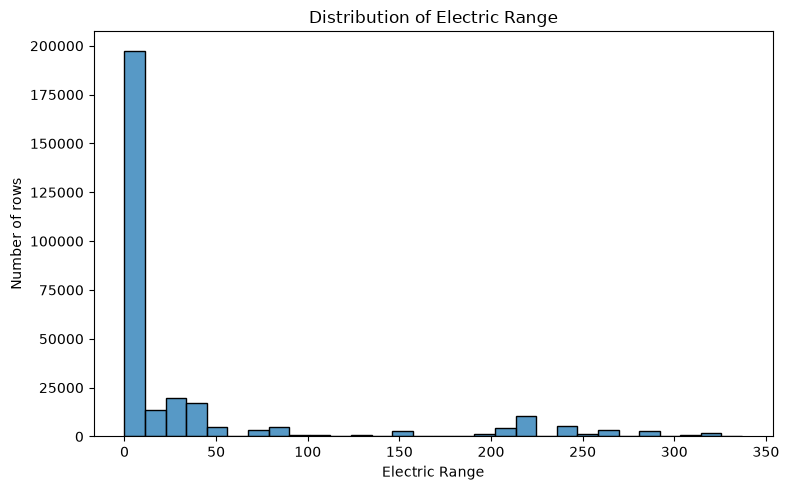

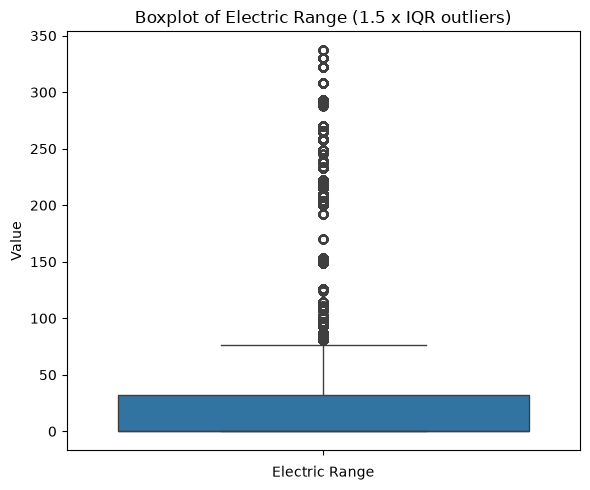

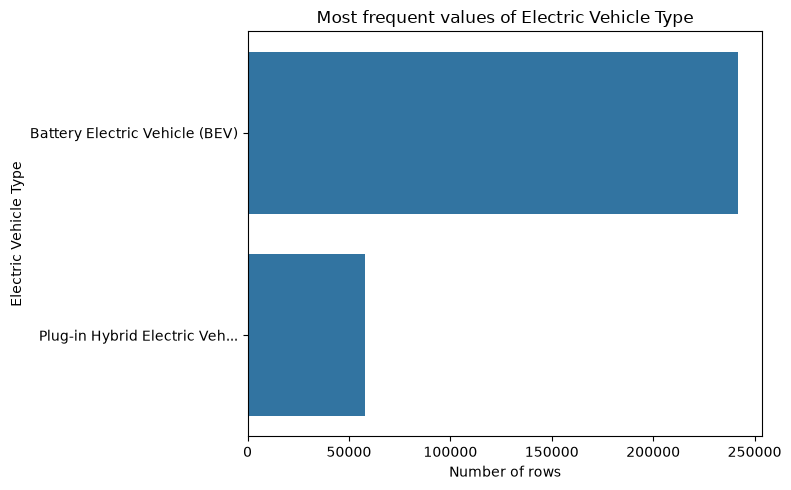

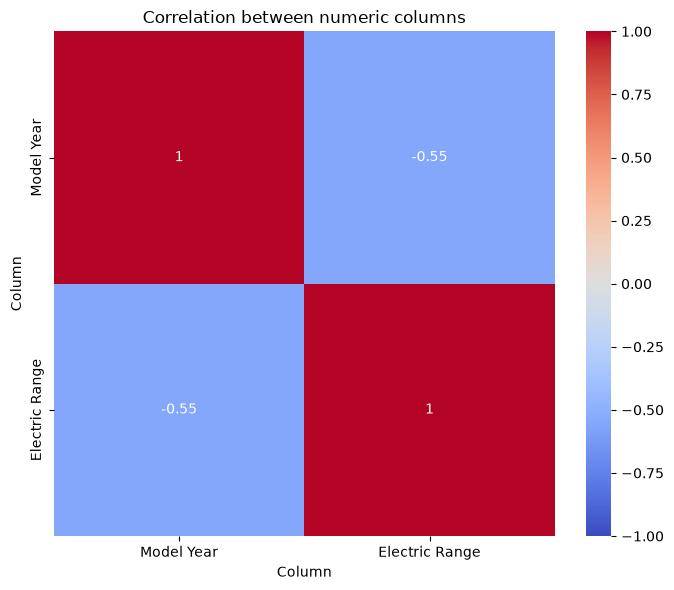

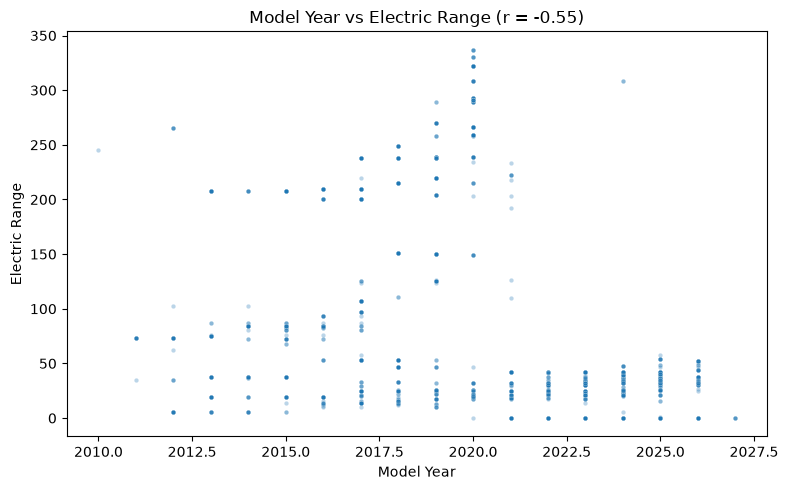

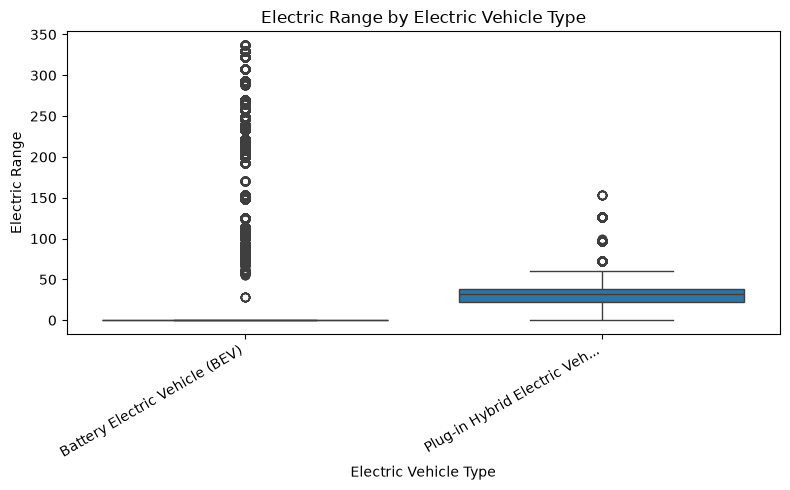

Profile saved to ../output/dataset_a


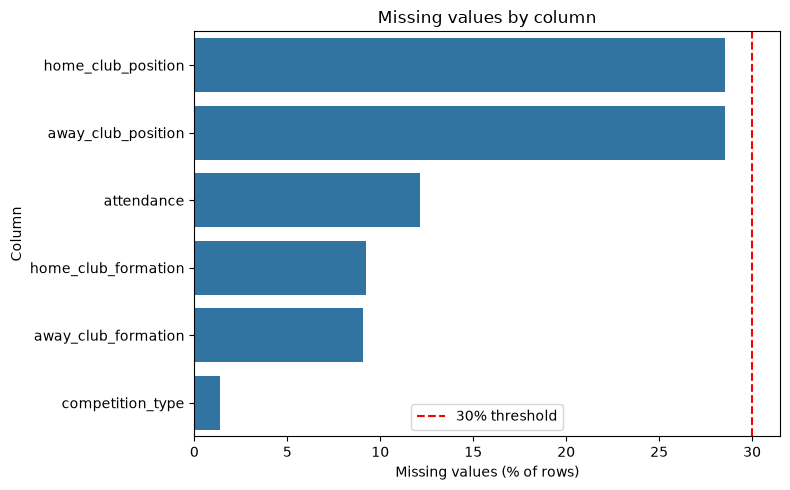

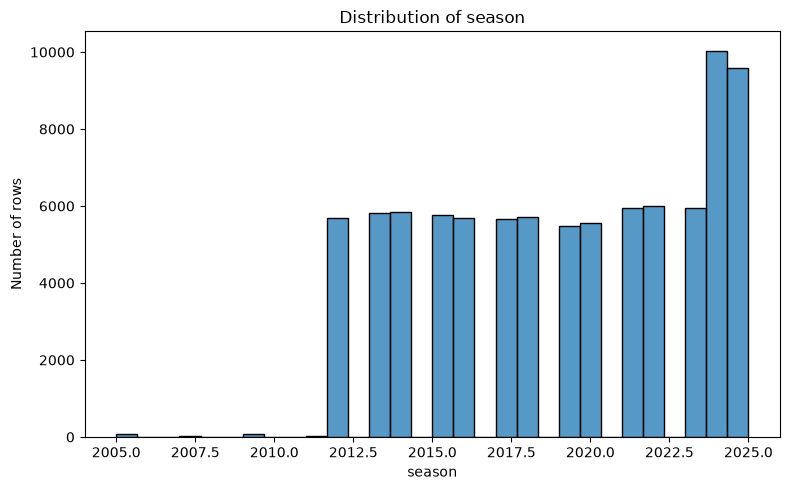

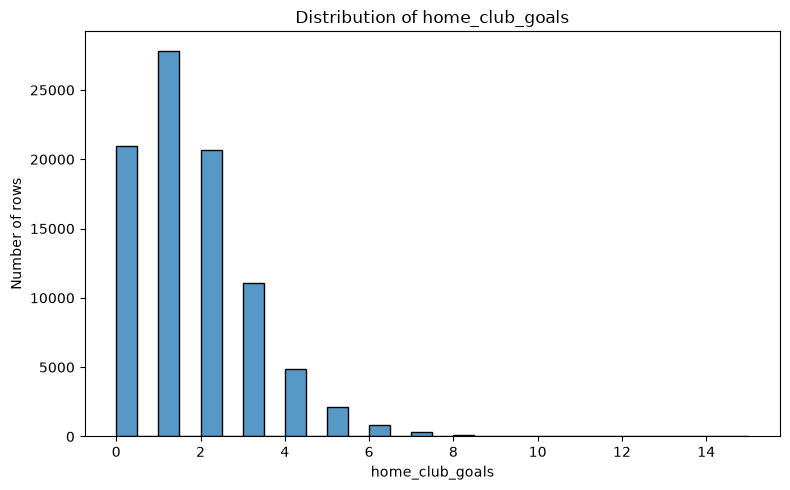

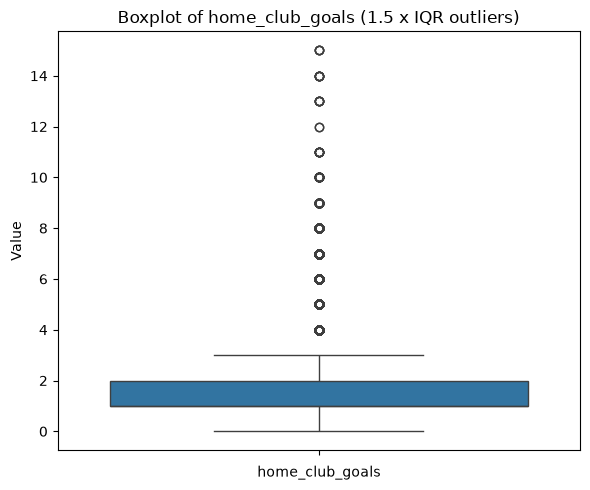

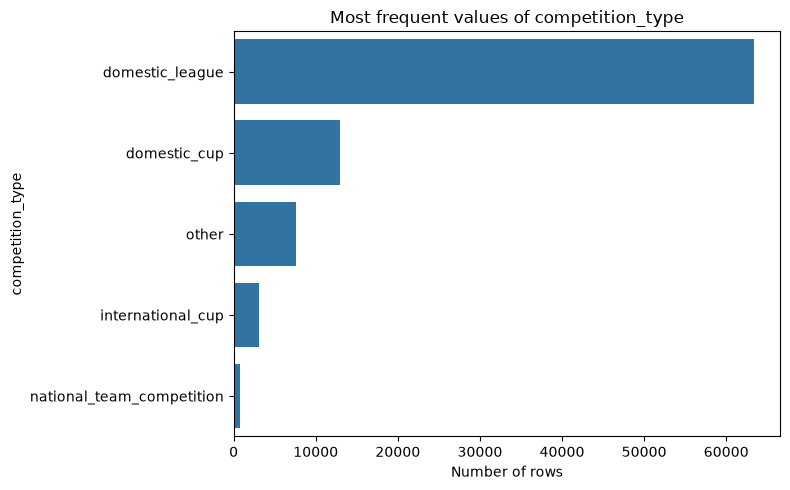

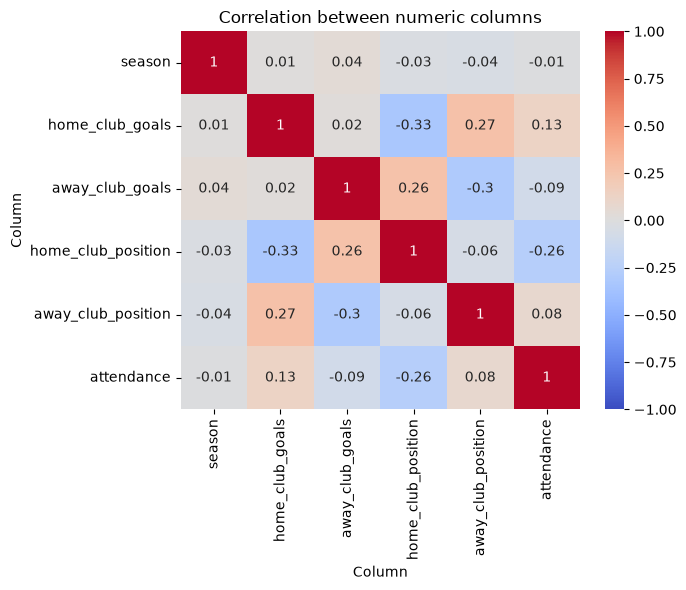

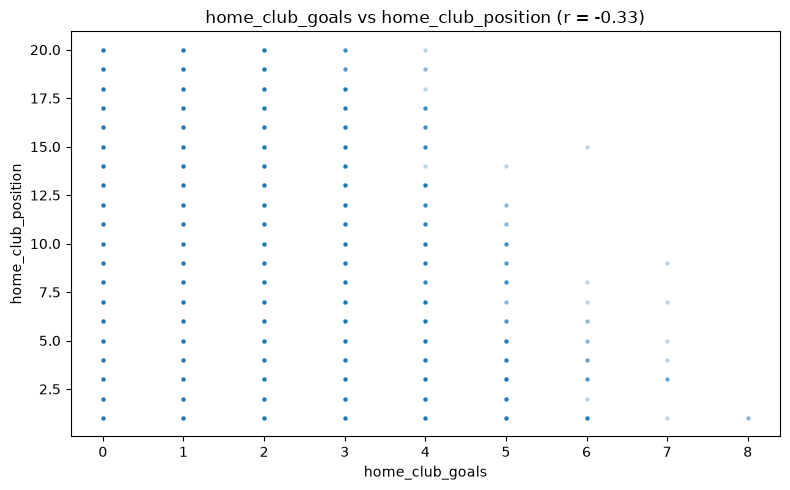

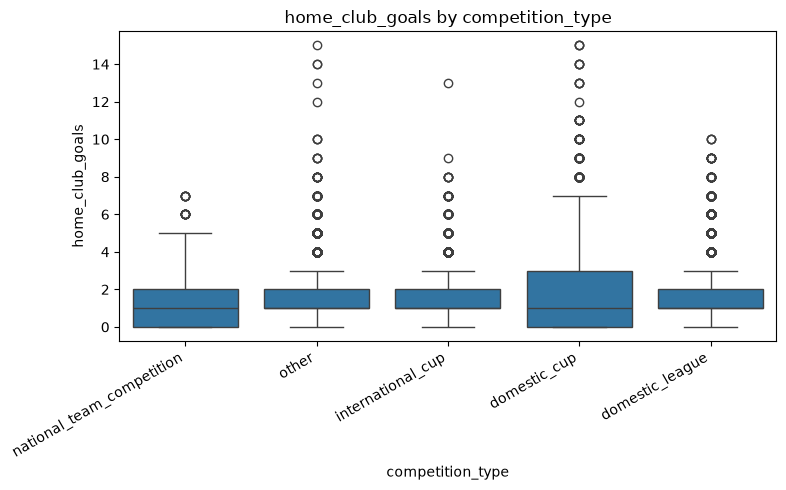

Profile saved to ../output/dataset_b


In [14]:
# Configuration: change only these lines to profile a different CSV
DATASET_A = "/Users/luis/Documents/automated_csv_profiler/data/ElectricVehiclePopulation.csv"
DATASET_B = "/Users/luis/Documents/automated_csv_profiler/data/games.csv"
USE_LLM = True

# Run the profiler on both datasets
generate_profile(DATASET_A, "../output/dataset_a", use_llm=USE_LLM)
generate_profile(DATASET_B, "../output/dataset_b", use_llm=USE_LLM)